# Multiclass
In this notebook I test multiclass classification using various models.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [77]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.datasets import make_classification
from sklearn.datasets import make_blobs

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier

import models.mlp_oop as O
from utils.encoding import one_hot_encode
from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
) 
from utils.plots import plot_confusion_matrix, plot_decision_boundary

## Iris Dataset

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_oh = one_hot_encode(y_train, n_classes=3)

In [ ]:
model = O.Sequential(
    O.Linear(4, 8, init_method='xavier', random_state=42),
    O.Tanh(),
    O.Linear(8, 3, init_method='xavier', random_state=43),
    O.Softmax(),
    task='multiclass',
)

loss_fn = O.CategoricalCrossEntropy()

In [ ]:
model.fit(
    X_train_scaled,
    y_train_oh,
    loss_fn=loss_fn,
    lr=0.1,
    n_iters=2000,
)

np.float64(1.0)

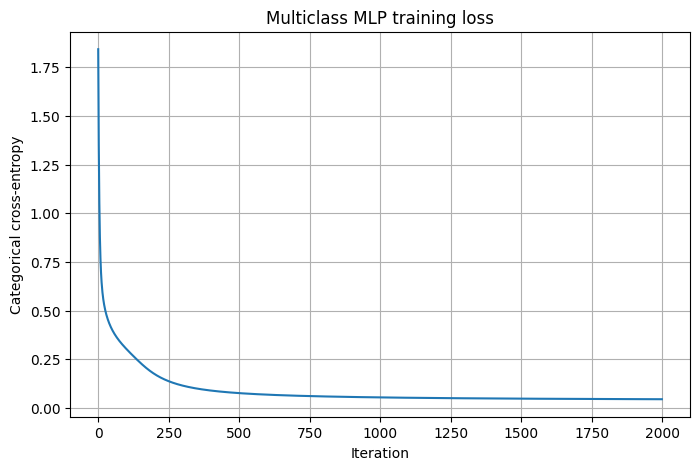

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Categorical cross-entropy")
plt.title("Multiclass MLP training loss")
plt.grid(True)
plt.show()

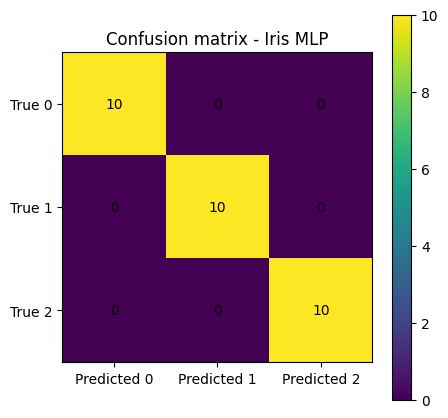

In [8]:
cm = confusion_matrix(y_test, preds)
plot_confusion_matrix(cm, [0,1,2], "Confusion matrix - Iris MLP")

## Synthetic Multiclass Dataset 1
This is a harder dataset than the iris one. We can see that although both models (`scratch` and `sklearn`) reach similar metrics and final loss, the `sklearn` one is much more efficient, and reaches the optimal state in just 121 steps, while our model takes 2000. The `sklearn` training then stops due to it having
```
tol=1e-4
n_iter_no_change=10
```
which stops the training when the loss is not improving by at least `tol` for `n_iter_no_change` consecutive iterations.

Also, `sklearn`'s SGD solver is not identical to the one employed in the scratch implementation, because it includes engineering details such as
- mini-batches
- shuffling every epoch
- stopping criteria
- learning-rate management
- numerical optimizations

while the scratch implementation is
- full-batch gradient descent
- fixed learning rate
- no stopping criterion

In particular, the custom implementation uses full-batch gradient descent and a fixed learning rate, while sklearn's MLPClassifier employs a more sophisticated optimization procedure and convergence criteria. As a result, sklearn reaches a comparable solution much faster.

In [ ]:
X, y = make_classification(
    n_samples=1500,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.08,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_oh = one_hot_encode(y_train, n_classes=3)

In [31]:
# Scratch
model = O.Sequential(
    O.Linear(4, 8, init_method='xavier', random_state=42),
    O.Tanh(),
    O.Linear(8, 3, init_method='xavier', random_state=43),
    O.Softmax(),
    task='multiclass',
)

loss_fn = O.CategoricalCrossEntropy()

# Sklearn
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation="tanh",
    solver="sgd",
    learning_rate_init=0.1,
    max_iter=2000,
    random_state=42,
)

In [34]:
results = {}

# Scratch
start = perf_counter()
model.fit(
    X_train_scaled,
    y_train_oh,
    loss_fn=loss_fn,
    lr=0.1,
    n_iters=2000,
)
fit_time = perf_counter() - start

start = perf_counter()
preds = model.predict(X_test_scaled)
predict_time = perf_counter() - start

results['Scratch'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds, average="macro"),
    "Recall": recall_score(y_test, preds, average="macro"),
    "F1": f1_score(y_test, preds, average="macro"),
    "final_loss": model.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

# Sklearn
start = perf_counter()
sklearn_mlp.fit(X_train_scaled, y_train)
fit_time = perf_counter() - start

start = perf_counter()
sklearn_preds = sklearn_mlp.predict(X_test_scaled)
predict_time = perf_counter() - start

results['Sklearn'] = {
    "Accuracy": accuracy_score(y_test, sklearn_preds),
    "Precision": precision_score(y_test, sklearn_preds, average="macro"),
    "Recall": recall_score(y_test, sklearn_preds, average="macro"),
    "F1": f1_score(y_test, sklearn_preds, average="macro"),
    "final_loss": sklearn_mlp.loss_curve_[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,final_loss,Fit time,Predict time
Scratch,0.786667,0.787662,0.786452,0.786483,0.498258,1.452655,0.000231
Sklearn,0.796667,0.796839,0.796719,0.796504,0.481512,0.248261,0.000571


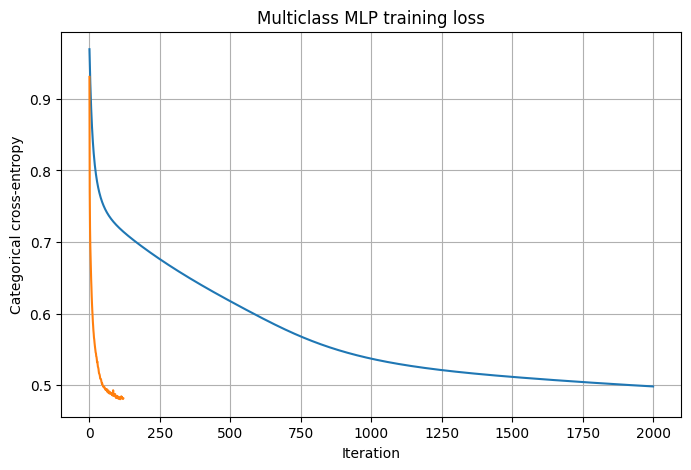

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history, label='Scratch')
plt.plot(sklearn_mlp.loss_curve_, label='Sklearn')
plt.xlabel("Iteration")
plt.ylabel("Categorical cross-entropy")
plt.title("Multiclass MLP training loss")
plt.legend()
plt.grid(True)
plt.show()

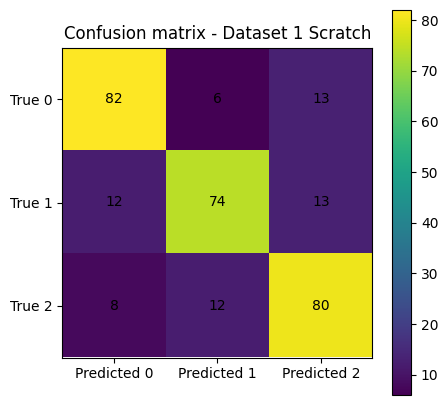

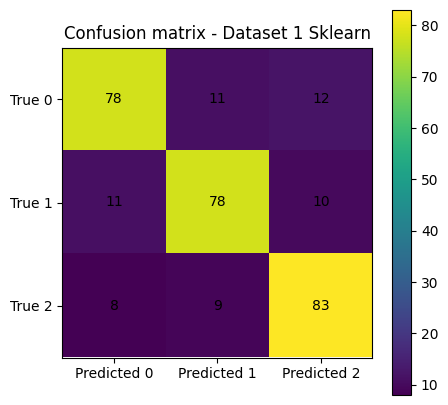

In [37]:
cm_scratch = confusion_matrix(y_test, preds)
cm_sklearn = confusion_matrix(y_test, sklearn_preds)

plot_confusion_matrix(cm_scratch, [0,1,2], "Confusion matrix - Dataset 1 Scratch")
plot_confusion_matrix(cm_sklearn, [0,1,2], "Confusion matrix - Dataset 1 Sklearn")

## Blobs Dataset

In [137]:
X, y = make_blobs(
    n_samples=10000,
    centers=6,
    n_features=2,
    cluster_std=1.5,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_oh = one_hot_encode(y_train, n_classes=6)

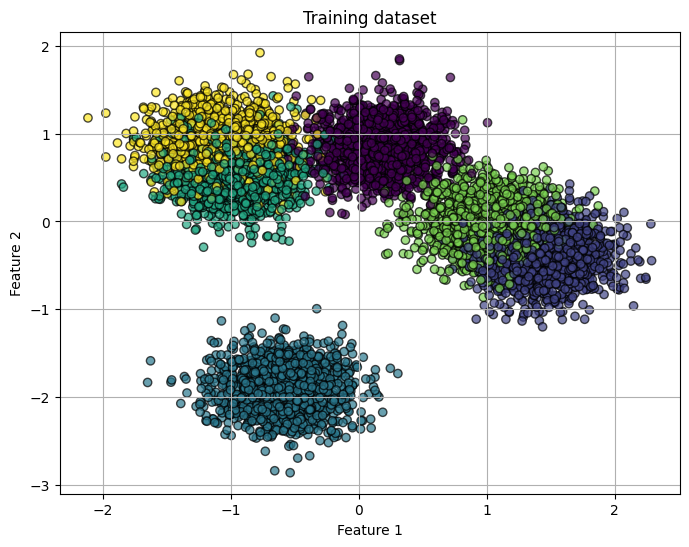

In [138]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

In [145]:
model = O.Sequential(
    O.Linear(2, 16, init_method='xavier', random_state=42),
    O.Tanh(),
    O.Linear(16, 32, init_method='xavier', random_state=43),
    O.Tanh(),
    O.Linear(32, 16, init_method='xavier', random_state=44),
    O.Tanh(),
    O.Linear(16, 6, init_method='xavier', random_state=45),
    O.Softmax(),
    task='multiclass',
)

loss_fn = O.CategoricalCrossEntropy()

In [146]:
results = {}

start = perf_counter()
model.fit(
    X_train_scaled,
    y_train_oh,
    loss_fn=loss_fn,
    lr=0.1,
    n_iters=2000,
)
fit_time = perf_counter() - start

start = perf_counter()
preds = model.predict(X_test_scaled)
predict_time = perf_counter() - start

results['Scratch'] = {
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds, average="macro"),
    "Recall": recall_score(y_test, preds, average="macro"),
    "F1": f1_score(y_test, preds, average="macro"),
    "final_loss": model.loss_history[-1],
    "Fit time": fit_time,
    "Predict time": predict_time,
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,final_loss,Fit time,Predict time
Scratch,0.8755,0.875861,0.875534,0.875364,0.289623,68.348421,0.005547


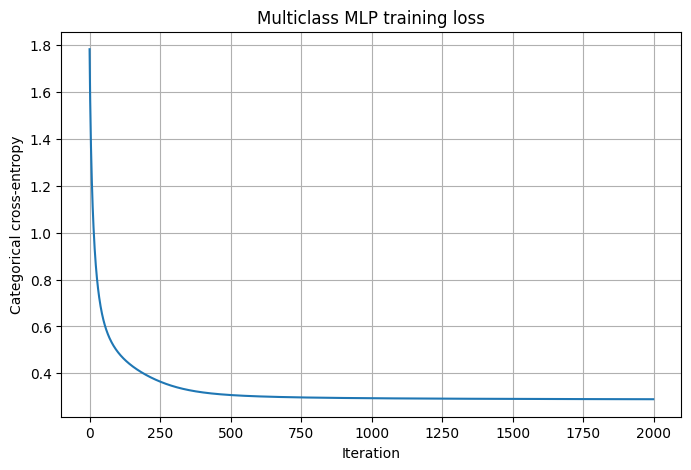

In [147]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history, label='Scratch')
plt.xlabel("Iteration")
plt.ylabel("Categorical cross-entropy")
plt.title("Multiclass MLP training loss")
plt.grid(True)
plt.show()

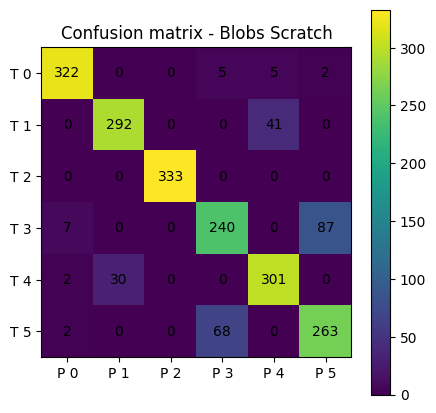

In [148]:
cm_scratch = confusion_matrix(y_test, preds)

plot_confusion_matrix(cm_scratch, list(range(y_train_oh.shape[1])), "Confusion matrix - Blobs Scratch")

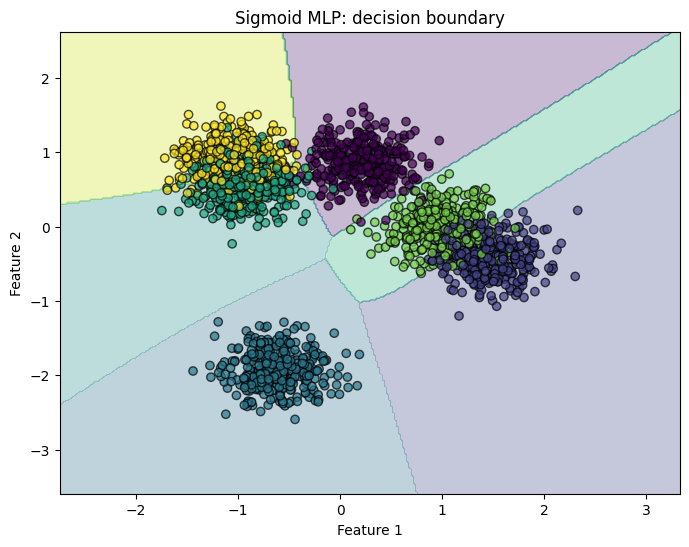

In [151]:
plot_decision_boundary(
    model,
    X_test_scaled,
    y_test,
    "Sigmoid MLP: decision boundary",
    plot_points=True
)